# Arquitectura Criptográfica y Estado Global de Ethereum

Este notebook explora los fundamentos técnicos de Ethereum. A diferencia de Solana (que prioriza la paralelización extrema y usa un reloj criptográfico), **Ethereum está diseñado como una única computadora mundial (EVM)** de estado global y secuencial.

Exploraremos su criptografía base, su modelo de cuentas, la estructura de sus bloques y cómo mantiene el consenso mediante Proof of Stake (Gasper).

## 1. Criptografía Base: secp256k1 y Keccak-256

Ethereum utiliza una criptografía distinta a Solana:

1.  **Firma Digital (Curva Elíptica):** Usa **secp256k1** (la misma que Bitcoin), cuya ecuación es $y^2 = x^3 + 7$. A diferencia de Ed25519 (Solana), secp256k1 requiere firmas ECDSA no deterministas (necesitan un número aleatorio seguro 'k' por firma, aunque hoy en día se usa RFC6979 para hacerlo determinista).
2.  **Función Hash:** Usa **Keccak-256** (un precursor del estándar SHA-3, pero con un padding distinto). Solana usa SHA-256 puro.

### Derivación de la Dirección Pública (`0x...`)
En Solana, la llave pública completa de 32 bytes en base58 es la dirección. En Ethereum el proceso es:
1. Generar la Llave Privada (32 bytes).
2. Derivar la Llave Pública sin comprimir (64 bytes, descartando el byte de prefijo).
3. Aplicar **Keccak-256** a esa llave pública.
4. Tomar los **últimos 20 bytes** del hash y agregar el prefijo `0x`.

In [1]:
!pip install eth-account pycryptodome

from eth_account import Account
from Crypto.Hash import keccak
import binascii

# Habilitar la creación de cuentas no auditadas (requerido por eth_account)
Account.enable_unaudited_hdwallet_features()

# 1. Generar una cuenta aleatoria
acct = Account.create()
private_key_hex = acct.key.hex()

# 2. En Ethereum, eth_account oculta el paso intermedio, pero la dirección se deriva
# tomando el Keccak256 de la clave pública (coordenadas X e Y concatenadas).
address = acct.address

print("--- CRIPTOGRAFÍA DE ETHEREUM ---")
print(f"Llave Privada (32 bytes): {private_key_hex}")
print(f"Dirección Pública (20 bytes): {address}")

def simular_derivacion_keccak(public_key_bytes):
    # Función hash Keccak-256
    k = keccak.new(digest_bits=256)
    k.update(public_key_bytes)
    full_hash = k.hexdigest()
    # Tomar los últimos 40 caracteres hex (20 bytes) y añadir 0x
    return '0x' + full_hash[-40:]

print("\nNota: La dirección en Ethereum siempre tiene 42 caracteres (0x + 40 caracteres hex).")

--- CRIPTOGRAFÍA DE ETHEREUM ---
Llave Privada (32 bytes): cd4314c2fc5427bdf694742c29e85f87a9756e5f6544ebbaeea9a5e3705bf023
Dirección Pública (20 bytes): 0x6137909954cA17b9ce3B7665c535Fc35e707b213

Nota: La dirección en Ethereum siempre tiene 42 caracteres (0x + 40 caracteres hex).


## 2. El Modelo de Cuentas (State)

A diferencia de Solana donde los programas son *stateless* (sin estado) y delegan los datos a "Data Accounts", **en Ethereum los contratos sí guardan su propio estado**.

Existen dos tipos de cuentas en Ethereum:
1. **Externally Owned Accounts (EOAs):** Cuentas de usuarios controladas por llaves privadas (ej. MetaMask). No tienen código.
2. **Contract Accounts:** Smart Contracts desplegados en la red. No tienen llave privada; son controlados por su código ejecutable.

### Estructura de UNA Cuenta en Ethereum (El Estado)
Cualquier cuenta (EOA o Contrato) tiene exactamente 4 campos a nivel de protocolo:
*   `nonce`: Un contador. En EOAs, es la cantidad de transacciones enviadas. En Contratos, es la cantidad de contratos que este contrato ha creado. Evita ataques de repetición.
*   `balance`: La cantidad de Wei (1 ETH = 10^18 Wei) que posee.
*   `storageRoot`: El hash raíz de un árbol Merkle que contiene TODAS las variables de estado del contrato (vacío para EOAs).
*   `codeHash`: El hash del código compilado de la EVM (vacío para EOAs).

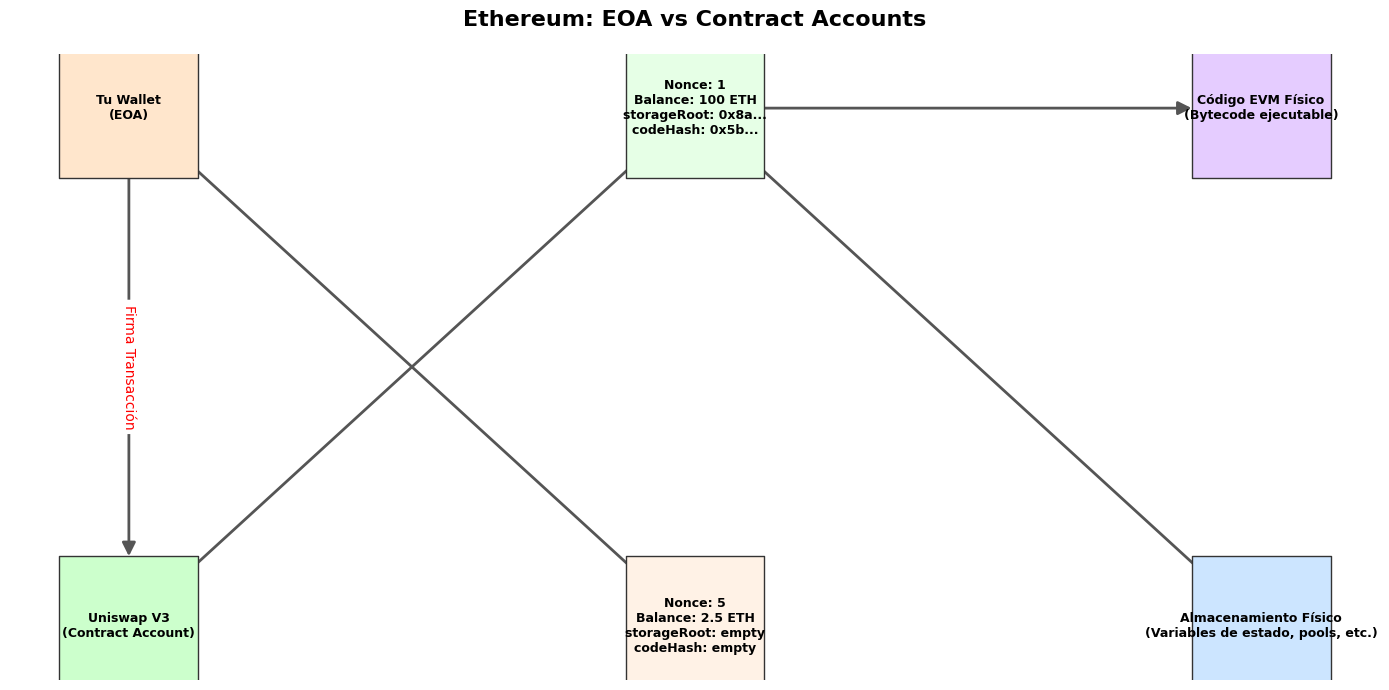

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_ethereum_accounts():
    G = nx.DiGraph()
    
    # Definir Nodos
    nodos = {
        "Tu Wallet\n(EOA)": {"layer": 0, "color": "#ffe6cc"},
        "Nonce: 5\nBalance: 2.5 ETH\nstorageRoot: empty\ncodeHash: empty": {"layer": 1, "color": "#fff2e6"},
        
        "Uniswap V3\n(Contract Account)": {"layer": 0, "color": "#ccffcc"},
        "Nonce: 1\nBalance: 100 ETH\nstorageRoot: 0x8a...\ncodeHash: 0x5b...": {"layer": 1, "color": "#e6ffe6"},
        
        "Almacenamiento Físico\n(Variables de estado, pools, etc.)": {"layer": 2, "color": "#cce5ff"},
        "Código EVM Físico\n(Bytecode ejecutable)": {"layer": 2, "color": "#e5ccff"}
    }
    
    for nodo, attrs in nodos.items():
        G.add_node(nodo, layer=attrs["layer"], color=attrs["color"])
        
    # Aristas
    edges = [
        ("Tu Wallet\n(EOA)", "Nonce: 5\nBalance: 2.5 ETH\nstorageRoot: empty\ncodeHash: empty"),
        ("Tu Wallet\n(EOA)", "Uniswap V3\n(Contract Account)"), # Transacción
        ("Uniswap V3\n(Contract Account)", "Nonce: 1\nBalance: 100 ETH\nstorageRoot: 0x8a...\ncodeHash: 0x5b..."),
        ("Nonce: 1\nBalance: 100 ETH\nstorageRoot: 0x8a...\ncodeHash: 0x5b...", "Almacenamiento Físico\n(Variables de estado, pools, etc.)"),
        ("Nonce: 1\nBalance: 100 ETH\nstorageRoot: 0x8a...\ncodeHash: 0x5b...", "Código EVM Físico\n(Bytecode ejecutable)")
    ]
    G.add_edges_from(edges)
    
    pos = nx.multipartite_layout(G, subset_key="layer", align='vertical')
    
    plt.figure(figsize=(14, 7))
    colors = [nx.get_node_attributes(G, 'color')[n] for n in G.nodes()]
    
    # Dibujar
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=10000, edgecolors="#333", node_shape="s")
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20, edge_color="#555", width=2, node_size=10000)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
    
    # Etiqueta de la arista EOA -> Contract
    nx.draw_networkx_edge_labels(G, pos, edge_labels={("Tu Wallet\n(EOA)", "Uniswap V3\n(Contract Account)"): "Firma Transacción"}, font_color="red")
    
    plt.title("Ethereum: EOA vs Contract Accounts", fontsize=16, fontweight="bold", pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_ethereum_accounts()

## 3. El Estado Global: Merkle Patricia Trie

Aquí radica **la mayor diferencia técnica con Solana**.

En Solana, cada cuenta es un archivo separado en el disco, lo que permite que 100 transacciones que tocan cuentas distintas se ejecuten simultáneamente (Sealevel).

En Ethereum, el estado no está disperso. Todas las cuentas de la red están conectadas en una estructura de datos criptográfica gigante llamada **Global State Trie** (Un Árbol Merkle Patricia Modificado).

1. **Seguridad Absoluta:** Cualquier cambio en el balance de UNA cuenta, cambia el hash de la raíz de todo el árbol. Esta `stateRoot` se guarda en el encabezado de cada bloque.
2. **Cuello de Botella:** Actualizar este árbol requiere lectura secuencial. Si tocas una cuenta, tienes que actualizar el árbol entero, lo que dificulta el paralelismo masivo.

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_merkle_trie():
    G = nx.DiGraph()
    
    nodos = {
        "State Root Hash\n(Se guarda en el Bloque)": {"layer": 0, "color": "#ffcc99"},
        "Branch Node A": {"layer": 1, "color": "#cce5ff"},
        "Branch Node B": {"layer": 1, "color": "#cce5ff"},
        "Leaf: Cta 0x123\n[nonce, bal, storage, code]": {"layer": 2, "color": "#ccffcc"},
        "Leaf: Cta 0x456\n[nonce, bal, storage, code]": {"layer": 2, "color": "#ccffcc"},
        "Leaf: Cta 0x789\n[nonce, bal, storage, code]": {"layer": 2, "color": "#ccffcc"}
    }
    
    for nodo, attrs in nodos.items():
        G.add_node(nodo, layer=attrs["layer"], color=attrs["color"])
        
    G.add_edges_from([
        ("State Root Hash\n(Se guarda en el Bloque)", "Branch Node A"),
        ("State Root Hash\n(Se guarda en el Bloque)", "Branch Node B"),
        ("Branch Node A", "Leaf: Cta 0x123\n[nonce, bal, storage, code]"),
        ("Branch Node A", "Leaf: Cta 0x456\n[nonce, bal, storage, code]"),
        ("Branch Node B", "Leaf: Cta 0x789\n[nonce, bal, storage, code]")
    ])
    
    pos = nx.multipartite_layout(G, subset_key="layer", align='horizontal')
    pos = {node: (coords[1], -coords[0]) for node, coords in pos.items()} # Rotate
    
    plt.figure(figsize=(10, 5))
    colors = [nx.get_node_attributes(G, 'color')[n] for n in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=4000, edgecolors="#333", node_shape="o")
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=15, edge_color="#555", width=2, node_size=4000)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")
    
    plt.title("El Cuello de Botella: Global State Trie\n(Si el saldo de 0x123 cambia, los hashes propagan el cambio hasta la raíz)", fontsize=14, fontweight="bold")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_merkle_trie()

## 4. Transacciones, Firmas (v,r,s) y el Mempool

En Ethereum, la transacción clásica (`Type 2` o EIP-1559) contiene:
- `nonce`: Qué número de transacción es para esta cuenta.
- `maxPriorityFeePerGas` (Tip para el minero/validador).
- `maxFeePerGas` (Máximo total dispuesto a pagar).
- `gasLimit`: Máximo poder de cómputo autorizado.
- `to`: Cuenta destino (EOA o Contrato).
- `value`: Cantidad de ETH enviada.
- `data`: Bytecode a ejecutar si el destino es un contrato.
- `v`, `r`, `s`: Componentes de la firma ECDSA.

### El Mempool y la red Gossip
Solana envía las transacciones *directamente* al nodo líder actual (no hay sala de espera global). 

Ethereum utiliza un **Mempool** (Memory Pool) global. Envías tu transacción a la red **Gossip** (P2P), y viaja de nodo en nodo esparciéndose por el mundo. Queda "flotando" en las RAMs de los validadores. Los validadores ordenan estas transacciones por la tarifa que pagan (`Tip`) y las empaquetan en el bloque. Quien paga más, entra primero (MEV - Maximal Extractable Value).

## 5. Bloques y Consenso: Proof of Stake (Gasper)

Tras "The Merge", Ethereum usa Proof of Stake operado por la **Beacon Chain**.

A diferencia del flujo continuo de Solana, Ethereum divide el tiempo estrictamente en:
*   **Slots (Ranuras):** Ocurren exactamente cada **12 segundos**. Cada slot tiene un (y solo un) Validador elegido para proponer un bloque. Si el validador está offline, el slot queda "Missed" (vacío).
*   **Epochs (Épocas):** Un grupo de **32 Slots** (aprox 6.4 minutos). Al final de cada época, un comité de validadores vota para justificar y "finalizar" la época anterior, garantizando criptográficamente que esos bloques nunca se revertirán (Finality).

A continuación, visualizamos la línea de tiempo de Ethereum.

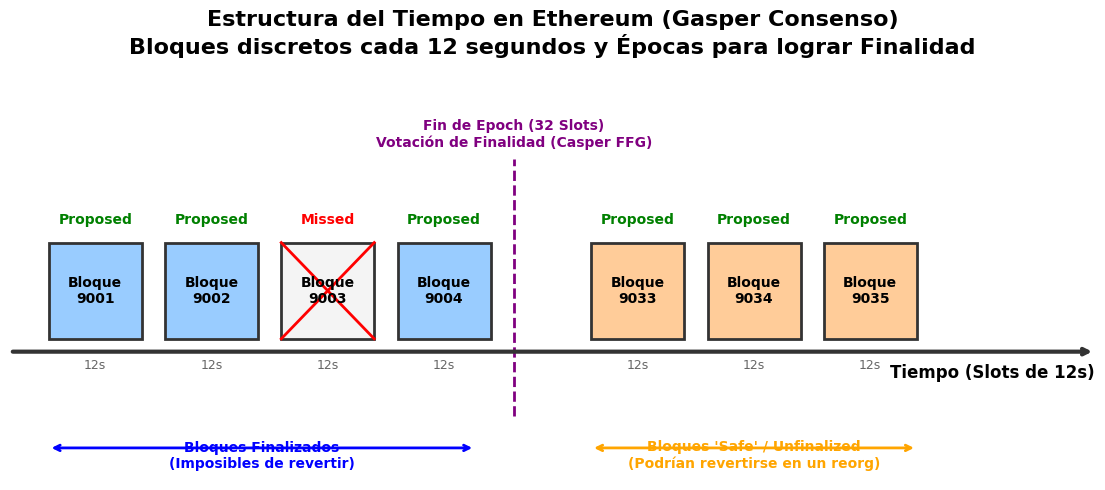

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

# Flecha de tiempo base
ax.annotate('', xy=(14, 2), xytext=(0, 2), arrowprops=dict(arrowstyle="->", lw=3, color="#333"))
ax.text(14, 1.6, "Tiempo (Slots de 12s)", ha='right', fontsize=12, fontweight='bold')

def draw_slot(ax, x, slot_num, status, color):
    # Dibujar bloque
    rect = patches.Rectangle((x, 2.2), 1.2, 1.5, linewidth=2, edgecolor='#333', facecolor=color)
    ax.add_patch(rect)
    ax.text(x + 0.6, 2.95, f"Bloque\n{slot_num}", ha='center', va='center', fontweight='bold', fontsize=10)
    ax.text(x + 0.6, 1.8, "12s", ha='center', va='center', fontsize=9, color="#666")
    
    if status == "Missed":
        ax.plot([x, x+1.2], [2.2, 3.7], color="red", lw=2)
        ax.plot([x, x+1.2], [3.7, 2.2], color="red", lw=2)
        ax.text(x + 0.6, 4.0, "Missed", ha='center', color="red", fontweight='bold')
    else:
        ax.text(x + 0.6, 4.0, "Proposed", ha='center', color="green", fontweight='bold')

# Epoch 1 (Finalizado)
draw_slot(ax, 0.5, 9001, "Proposed", "#99ccff")
draw_slot(ax, 2.0, 9002, "Proposed", "#99ccff")
draw_slot(ax, 3.5, 9003, "Missed", "#f4f4f4") # Validador offline
draw_slot(ax, 5.0, 9004, "Proposed", "#99ccff")

# Separador de Epoch
ax.plot([6.5, 6.5], [1, 5], color="purple", linestyle="--", lw=2)
ax.text(6.5, 5.2, "Fin de Epoch (32 Slots)\nVotación de Finalidad (Casper FFG)", ha='center', color="purple", fontweight='bold')

# Epoch 2 (En progreso)
draw_slot(ax, 7.5, 9033, "Proposed", "#ffcc99")
draw_slot(ax, 9.0, 9034, "Proposed", "#ffcc99")
draw_slot(ax, 10.5, 9035, "Proposed", "#ffcc99")

# Corchetes debajo para indicar estado
ax.annotate('', xy=(6.0, 0.5), xytext=(0.5, 0.5), arrowprops=dict(arrowstyle="<->", lw=2, color="blue"))
ax.text(3.25, 0.2, "Bloques Finalizados\n(Imposibles de revertir)", ha='center', color="blue", fontweight='bold')

ax.annotate('', xy=(11.7, 0.5), xytext=(7.5, 0.5), arrowprops=dict(arrowstyle="<->", lw=2, color="orange"))
ax.text(9.6, 0.2, "Bloques 'Safe' / Unfinalized\n(Podrían revertirse en un reorg)", ha='center', color="orange", fontweight='bold')

plt.title("Estructura del Tiempo en Ethereum (Gasper Consenso)\nBloques discretos cada 12 segundos y Épocas para lograr Finalidad", 
          fontsize=16, fontweight="bold", pad=30)

plt.xlim(0, 14)
plt.ylim(0, 6)
plt.show()


## 6. Evolución de Ethereum: Hard Forks y Cambios Estructurales

Ethereum no es estático; se actualiza mediante **Hard Forks** (bifurcaciones duras) que introducen cambios a nivel de protocolo (EIPs - *Ethereum Improvement Proposals*). A diferencia de Solana que realiza actualizaciones de software más iterativas, los Hard Forks de Ethereum requieren que toda la red actualice sus clientes simultáneamente o corren el riesgo de quedar en una cadena dividida.

A continuación, detallamos las transiciones arquitectónicas más importantes en la historia de la red:

### A. The DAO Fork (2016) - *La Bifurcación Filosófica*
*   **El Incidente:** Un hacker explotó una vulnerabilidad de reentrada (*reentrancy*) en el contrato inteligente "The DAO", robando millones de Ether.
*   **El Cambio Técnico:** Fue una intervención manual de estado (State Intervention). Se modificó el código del cliente para mover forzosamente los fondos del contrato del hacker a un contrato de recuperación.
*   **Consecuencia:** Rompió el principio de "Código es Ley". La comunidad se dividió, dando nacimiento a **Ethereum Classic (ETC)** (la cadena original que no revirtió el hackeo) y **Ethereum (ETH)** (la cadena intervenida).

### B. EIP-1559 (London Upgrade, 2021) - *Revolución en el Mercado de Tarifas*
Antes de EIP-1559, Ethereum usaba una subasta de primer precio ciego (pagabas lo que ofrecías, y si ofrecías poco, tu transacción quedaba estancada en el Mempool infinitamente).
*   **Cambio Estructural:** Se introdujo una tarifa base dinámica (**Base Fee**) que el protocolo quema (destruye), reduciendo la inflación de ETH.
*   **Tip / Priority Fee:** Se añadió una propina opcional para incentivar a los validadores a incluir la transacción más rápido.
*   **Tamaño de Bloque Dinámico:** Los bloques ya no tienen un límite fijo de Gas estricto. El tamaño objetivo es de 15M de Gas, pero puede expandirse hasta 30M en momentos de alta congestión (y la *Base Fee* aumenta algorítmicamente para disuadir el spam).
*   **Obsoleto:** Las transacciones *Legacy* (Type 0) siguen funcionando por retrocompatibilidad, pero se consideran subóptimas frente a las nuevas *Type 2*.

### C. The Merge (Paris Upgrade, 2022) - *El Adiós a los Mineros (Proof of Work a Proof of Stake)*
Este fue el cambio técnico más ambicioso en la historia de las criptomonedas, fusionando la cadena de ejecución (Execution Layer) con la cadena de consenso (Beacon Chain).

**Cambios Profundos:**
1.  **Eliminación de Nakamoto Consensus (PoW):** El concepto de "dificultad de minería" y "Nonces" para resolver puzzles criptográficos (Keccak-256 masivo) **dejó de existir**. Los mineros de GPU quedaron obsoletos de la noche a la mañana.
2.  **Nuevo Consenso (Gasper):** Se introdujo *Casper FFG* (mecanismo de finalidad) combinado con *LMD GHOST* (regla de elección de bifurcación). 
3.  **Slots y Epochs:** El tiempo de bloque pasó de ser probabilístico (~13-14 segundos basados en el hashrate global) a ser estrictamente determinista (Slots exactos de 12 segundos).
4.  **Separación de Clientes:** Para correr un nodo, ahora **obligatoriamente** necesitas ejecutar dos piezas de software que se comunican por una API interna (Engine API): un Cliente de Ejecución (ej. Geth, Nethermind) y un Cliente de Consenso (ej. Prysm, Lighthouse).
5.  **Reducción de Emisión:** La creación de nuevos ETH se redujo en ~90%, pasando de recompensar el gasto energético masivo a recompensar el capital en *stake* (mínimo 32 ETH para ser validador independiente).

### D. Shapella (2023) - *Habilitación de Retiros (Withdrawals)*
*   **El Cambio:** Habilitó a los validadores de Proof of Stake a retirar (unstake) sus 32 ETH y las recompensas acumuladas desde la Beacon Chain hacia la capa de ejecución (EOAs).
*   **Modificación Técnica:** Introdujo operaciones de retiro a nivel de sistema (System-level operations) que actualizan los balances de las cuentas directamente sin requerir transacciones iniciadas por usuarios o consumo de Gas, empujando el estado desde la capa de consenso a la de ejecución.

### E. Dencun Upgrade (EIP-4844 / Protodanksharding, 2024) - *Escalabilidad de Capa 2 (L2)*
Ethereum decidió que no escalaría masivamente en su Capa 1 (L1) (a diferencia de Solana), sino que usaría Rollups (Arbitrum, Optimism, Base).

*   **El Problema:** Los Rollups procesaban transacciones baratas, pero publicar la prueba criptográfica de vuelta en Ethereum (usando el campo `calldata` de las transacciones) era excesivamente caro, haciendo que las comisiones en L2 siguieran altas.
*   **La Solución (Blobs):** Se introdujeron las **Blob-carrying Transactions** (Type 3). Un "Blob" es un gran bloque de datos (hasta 128 KB por blob) adjunto a una transacción. 
*   **Separación de Almacenamiento:** El gran cambio de paradigma es que los datos del Blob **NO** son accesibles por la EVM (los Smart Contracts no pueden leerlos). Solo garantizan que los datos estuvieron disponibles para descarga por un tiempo limitado (~18 días).
*   **Propagación y Poda:** Los Blobs tienen su propio mercado de tarifas independiente y, crucialmente, los nodos descartan físicamente estos datos después del período de retención, evitando inflar infinitamente el tamaño de la base de datos global de Ethereum.

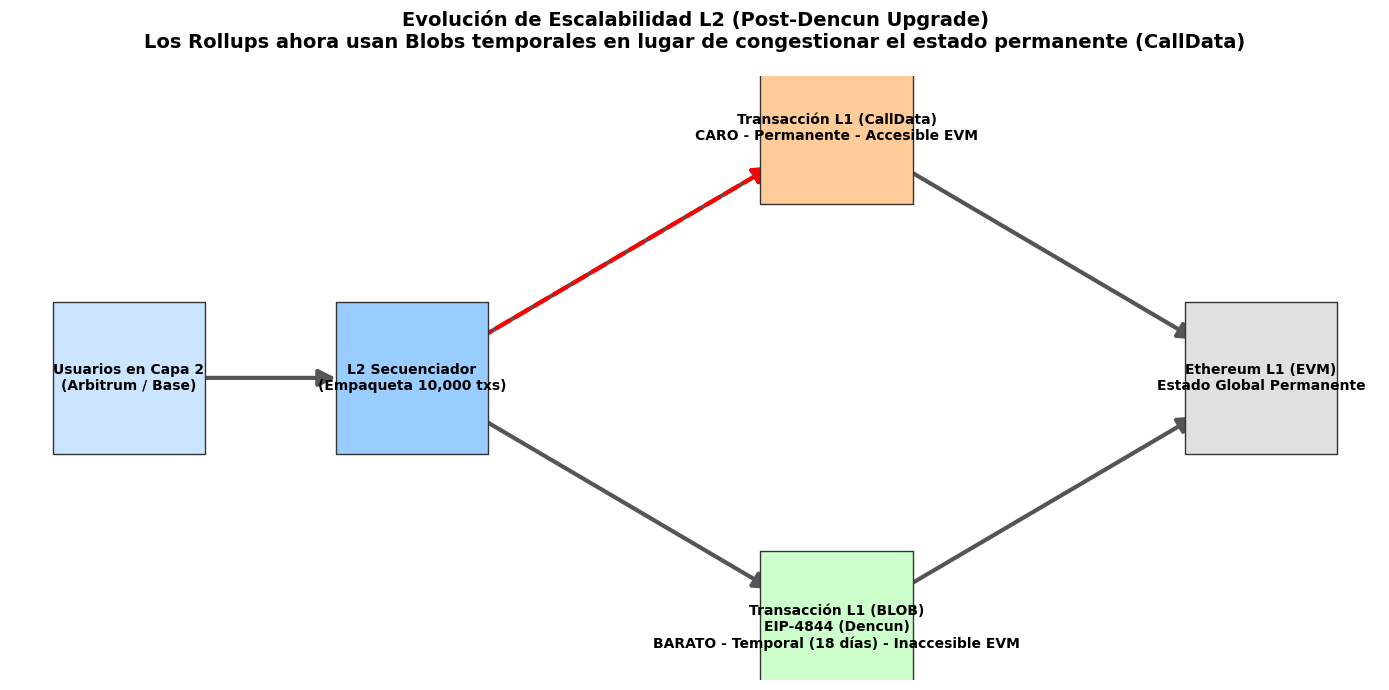

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# Graficando la Separación L1 vs L2 (Rollups + Blobs post-Dencun)
fig, ax = plt.subplots(figsize=(14, 7))

G = nx.DiGraph()
nodos = {
    "Usuarios en Capa 2\n(Arbitrum / Base)": {"layer": 0, "color": "#cce5ff", "pos": (1, 3)}, 
    "L2 Secuenciador\n(Empaqueta 10,000 txs)": {"layer": 1, "color": "#99ccff", "pos": (3, 3)},
    
    "Transacción L1 (CallData)\nCARO - Permanente - Accesible EVM": {"layer": 2, "color": "#ffcc99", "pos": (6, 4)},
    "Transacción L1 (BLOB)\nEIP-4844 (Dencun)\nBARATO - Temporal (18 días) - Inaccesible EVM": {"layer": 2, "color": "#ccffcc", "pos": (6, 2)},
    
    "Ethereum L1 (EVM)\nEstado Global Permanente": {"layer": 3, "color": "#e0e0e0", "pos": (9, 3)}
}

for n, d in nodos.items():
    G.add_node(n, pos=d['pos'], color=d['color'])

G.add_edges_from([
    ("Usuarios en Capa 2\n(Arbitrum / Base)", "L2 Secuenciador\n(Empaqueta 10,000 txs)"),
    ("L2 Secuenciador\n(Empaqueta 10,000 txs)", "Transacción L1 (CallData)\nCARO - Permanente - Accesible EVM"),
    ("L2 Secuenciador\n(Empaqueta 10,000 txs)", "Transacción L1 (BLOB)\nEIP-4844 (Dencun)\nBARATO - Temporal (18 días) - Inaccesible EVM"),
    ("Transacción L1 (CallData)\nCARO - Permanente - Accesible EVM", "Ethereum L1 (EVM)\nEstado Global Permanente"),
    ("Transacción L1 (BLOB)\nEIP-4844 (Dencun)\nBARATO - Temporal (18 días) - Inaccesible EVM", "Ethereum L1 (EVM)\nEstado Global Permanente")
])

pos = nx.get_node_attributes(G, 'pos')
colors = [nx.get_node_attributes(G, 'color')[n] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=colors, node_shape="s", node_size=12000, edgecolors="#333", ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=25, edge_color="#555", width=3, node_size=12000, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)

# Marcar la ruta obsoleta (CallData para rollups)
nx.draw_networkx_edges(G, pos, edgelist=[("L2 Secuenciador\n(Empaqueta 10,000 txs)", "Transacción L1 (CallData)\nCARO - Permanente - Accesible EVM")], 
                       edge_color="red", style="dashed", width=3, arrows=True, arrowsize=25, node_size=12000, ax=ax)

ax.set_title("Evolución de Escalabilidad L2 (Post-Dencun Upgrade)\nLos Rollups ahora usan Blobs temporales en lugar de congestionar el estado permanente (CallData)", 
             fontsize=14, fontweight="bold", pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()


## 7. Anatomía y Evolución del Bloque de Ethereum

La estructura interna de un bloque en Ethereum ha mutado drásticamente a lo largo de los años. A diferencia de Solana, donde la estructura base ha sido muy estable, cada gran actualización de Ethereum ha agregado, modificado o "matado" campos en el encabezado del bloque (*Block Header*).

### Campos Clásicos (Desde 2015)
Todo bloque siempre ha tenido:
*   `parentHash`: El hash del bloque anterior (la cadena).
*   `stateRoot`: La raíz del Árbol Merkle Patricia Global tras ejecutar todas las transacciones.
*   `transactionsRoot`: La raíz de Merkle de las transacciones de este bloque.
*   `receiptsRoot`: La raíz de los "recibos" (logs y eventos emitidos por contratos).
*   `gasUsed` y `gasLimit`: Cuánto cómputo se usó vs el máximo permitido.

### Campos Obsoletos (Zombis post-Merge)
Con el fin de la minería (PoW), varios campos perdieron su utilidad original pero **se mantienen en la estructura por retrocompatibilidad** con herramientas antiguas (con valores fijos a cero):
*   `ommersHash` (Uncles): Antes, si dos mineros encontraban un bloque casi al mismo tiempo, el perdedor ("Tío" u Ommer) se incluía para darle una pequeña recompensa y asegurar la red. En PoS, al haber un solo proponente elegido por Slot, **los Ommers ya no existen** (su hash siempre es vacío).
*   `difficulty`: Antes marcaba cuán difícil era minar. Ahora está **fijo en 0**.
*   `nonce`: Antes era el número mágico que el minero debía adivinar. Ahora está **fijo en 0x000...**
*   `mixHash`: Antes se usaba junto al nonce para probar el trabajo (Ethash). Ahora fue renombrado a `prevRandao` y contiene la aleatoriedad provista por la Beacon Chain.

### Nuevos Campos (Las Actualizaciones)
*   **EIP-1559 (London):** Agregó `baseFeePerGas`, indicando el precio base mínimo obligatorio (que se quema) para ese bloque.
*   **Shapella:** Agregó `withdrawalsRoot`, el hash de los retiros de los validadores de la Beacon Chain hacia cuentas de ejecución.
*   **Dencun (EIP-4844):** Agregó `blobGasUsed` y `excessBlobGas`, para rastrear independientemente cuánto espacio temporal (Blobs) se consumió en este bloque.

### La Separación de Capas (El Bloque Moderno)
Hoy en día, lo que llamamos "Bloque de Ethereum" son en realidad dos estructuras anidadas. El **Cliente de Consenso** crea un *Beacon Block* que contiene información de PoS (votos, atestaciones, slashings). Dentro de este Beacon Block, va incrustado el **Execution Payload** (generado por el *Cliente de Ejecución* como Geth), que contiene las transacciones y el estado de la EVM.

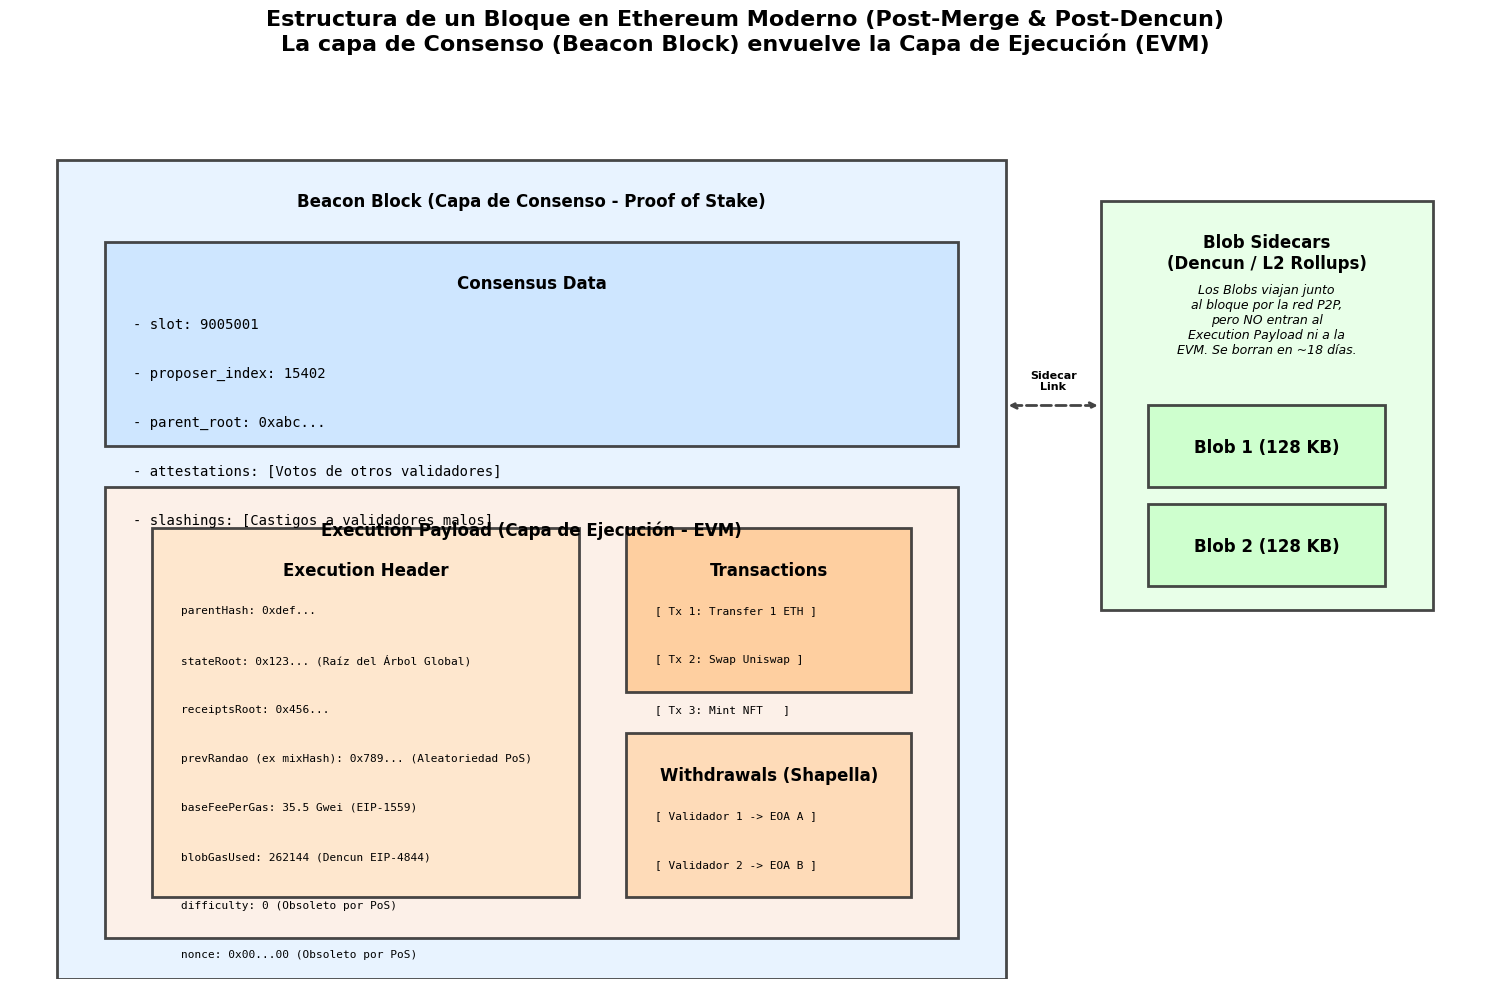

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(15, 10))
ax.axis('off')

def draw_box(ax, x, y, w, h, title, color, text_lines=[], font_size=9):
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='#333', facecolor=color, alpha=0.9, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.4, title, ha='center', va='top', fontsize=12, fontweight='bold', zorder=3)
    
    y_text = y + h - 1.0
    for line in text_lines:
        ax.text(x + 0.3, y_text, line, ha='left', va='center', fontsize=font_size, family='monospace', zorder=3)
        y_text -= 0.6

# 1. BEACON BLOCK (Capa de Consenso)
draw_box(ax, 0, 0, 10, 10, "Beacon Block (Capa de Consenso - Proof of Stake)", "#e6f2ff")

# Campos de Consenso
consensus_text = [
    "- slot: 9005001",
    "- proposer_index: 15402",
    "- parent_root: 0xabc...",
    "- attestations: [Votos de otros validadores]",
    "- slashings: [Castigos a validadores malos]"
]
draw_box(ax, 0.5, 6.5, 9, 2.5, "Consensus Data", "#cce5ff", consensus_text, 10)

# 2. EXECUTION PAYLOAD (Capa de Ejecución - EVM)
draw_box(ax, 0.5, 0.5, 9, 5.5, "Execution Payload (Capa de Ejecución - EVM)", "#fff0e6")

# Execution Header
header_text = [
    "parentHash: 0xdef...",
    "stateRoot: 0x123... (Raíz del Árbol Global)",
    "receiptsRoot: 0x456...",
    "prevRandao (ex mixHash): 0x789... (Aleatoriedad PoS)",
    "baseFeePerGas: 35.5 Gwei (EIP-1559)",
    "blobGasUsed: 262144 (Dencun EIP-4844)",
    "difficulty: 0 (Obsoleto por PoS)",
    "nonce: 0x00...00 (Obsoleto por PoS)"
]
draw_box(ax, 1, 1.0, 4.5, 4.5, "Execution Header", "#ffe6cc", header_text, 8)

# Listas internas de la ejecución
lists_text = [
    "[ Tx 1: Transfer 1 ETH ]",
    "[ Tx 2: Swap Uniswap ]",
    "[ Tx 3: Mint NFT   ]"
]
draw_box(ax, 6, 3.5, 3, 2.0, "Transactions", "#ffcc99", lists_text, 8)

withdrawals_text = [
    "[ Validador 1 -> EOA A ]",
    "[ Validador 2 -> EOA B ]"
]
draw_box(ax, 6, 1.0, 3, 2.0, "Withdrawals (Shapella)", "#ffd9b3", withdrawals_text, 8)

# 3. BLOB SIDECARS (Post-Dencun)
draw_box(ax, 11, 4.5, 3.5, 5, "Blob Sidecars\n(Dencun / L2 Rollups)", "#e6ffe6")
ax.text(12.75, 8.5, "Los Blobs viajan junto\nal bloque por la red P2P,\npero NO entran al\nExecution Payload ni a la\nEVM. Se borran en ~18 días.", 
        ha='center', va='top', fontsize=9, wrap=True, style='italic')

draw_box(ax, 11.5, 6, 2.5, 1, "Blob 1 (128 KB)", "#ccffcc")
draw_box(ax, 11.5, 4.8, 2.5, 1, "Blob 2 (128 KB)", "#ccffcc")

# Flechas de relación
ax.annotate('', xy=(11, 7.0), xytext=(10, 7.0), arrowprops=dict(arrowstyle="<->", lw=2, color="#444", linestyle="dashed"))
ax.text(10.5, 7.2, "Sidecar\nLink", ha='center', fontsize=8, fontweight='bold')

plt.title("Estructura de un Bloque en Ethereum Moderno (Post-Merge & Post-Dencun)\nLa capa de Consenso (Beacon Block) envuelve la Capa de Ejecución (EVM)", 
          fontsize=16, fontweight="bold", pad=20)

plt.xlim(-0.5, 15)
plt.ylim(0, 11)
plt.tight_layout()
plt.show()
